Banco de dados cotações

In [1]:
import time
start = time.process_time()
import pandas as pd
pd.options.display.float_format = '{:,}'.format
from datetime import datetime, timedelta
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import textwrap
import sys
import os
import base64
from io import BytesIO

#Gráficos
import seaborn as sns
import matplotlib.ticker as ticker

#Bibliotecas para envio de e-mail
import smtplib
from email.message import EmailMessage
from email.headerregistry import Address
from email.utils import make_msgid
#from dash import Dash, dcc, html, dash_table, callback, ctx
#from dash.dependencies import Output, Input
#from dash.exceptions import PreventUpdate
#tabelas

sys.path.append(os.path.abspath('C:/Users/mateuslm/COMPANY/Projetos/Arquivos_PY'))

#funcoes
import functions as fc

#Precisam de atualização
import contatos
import customers_info
import representantes as reps

#Não precisam de atualização
from db_quotes import quotes

Conexão bem-sucedida!
Consulta bem-sucedida:


In [2]:
controle_de_atualização = []

for i in [contatos,customers_info,reps]:
    controle_de_atualização.extend(i.controle_de_atualização)
    
pd.DataFrame(controle_de_atualização)

,Arquivo,Data de Modificação,Caminho
0,"[Banco de dados, Contatos.xlsx]",2026-01-30 13:21:54.960571,Q:/GROUPS/BR_SC_JGS_WMO_VENDAS_TECNICAS_CNEE/V...
1,"[Banco de dados, Cadastro clientes - Mateus_PB...",2026-01-21 14:56:59.445114,Q:\GROUPS\BR_SC_JGS_WMO_VENDAS_TECNICAS_CNEE\V...
2,"[Banco de dados, Lista de representantes.xlsx]",2026-01-07 07:20:24.292043,Q:\GROUPS\BR_SC_JGS_WMO_VENDAS_TECNICAS_CNEE\V...


Definição de variáveis de entrada

In [3]:
lista_representantes = reps.df_reps

current_year = datetime.now().year

anos = [str(current_year-2),
        str(current_year-1),
        str(current_year),
       ]

anos_int = [int(i) for i in anos]


quotes['Ano de criação'] = quotes['Data de criação'].apply(fc.extrair_ano)
quotes = quotes.loc[(quotes['Ano de criação'].isin(anos_int)) &
                    (quotes['Código organização de vendas'].isin(['1001','1004','1019']))
                   ]
quotes['Organização de vendas'] = quotes['Código organização de vendas'].replace({'1001':'WEG Motores',
                                                                                  '1004':'WEG Motores',
                                                                                  '1019':'WEG Cestari'
                                                                                 })


#Extraindo a última cotação para anexar ao e-mail, independente do status
last_quotes = quotes
last_quotes['Revisão'] = pd.to_numeric(last_quotes['Revisão'], errors='coerce')
last_quotes = last_quotes.loc[last_quotes.groupby(['Cotação','Descrição do produto'])['Revisão'].idxmax()].reset_index(drop=True)

anos = [str(current_year-1),
        str(current_year),
       ]

anos_int = [int(i) for i in anos]

quotes = quotes.loc[(quotes['Ano de criação'].isin(anos_int))]

quotes_criadas = quotes.loc[quotes['Revisão']==0]
quotes_ult_rev = quotes.loc[(quotes['Status'].isin(['underApprovalByCustomer',
                                                    'expired',
                                                    'underApprovalByWEG'
                                                    ]))]
quotes_rej = quotes.loc[quotes['Status']=='rejected']
quotes_concluded = quotes.loc[quotes['Status']=='concluded']

quotes_concluded['Data de fechamento'] = pd.to_datetime(quotes_concluded['Data de fechamento'], dayfirst=True, errors='coerce')
quotes_concluded['Ano de fechamento'] = quotes_concluded['Data de fechamento'].dt.year

customers_info.df_customers_info = customers_info.df_customers_info.sort_values(by='Analista de vendas').drop_duplicates(subset=['Código cliente','Código organização de vendas'], keep='first')


df_customer_analista_engenheiro = customers_info.df_customers_info[['Código cliente','Engenheiro de aplicação','Analista de vendas']].drop_duplicates()

C:\Users\mateuslm\AppData\Local\Temp\ipykernel_12008\750014990.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  quotes['Organização de vendas'] = quotes['Código organização de vendas'].replace({'1001':'WEG Motores',
C:\Users\mateuslm\AppData\Local\Temp\ipykernel_12008\750014990.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  last_quotes['Revisão'] = pd.to_numeric(last_quotes['Revisão'], errors='coerce')
C:\Users\mateuslm\AppData\Local\Temp\ipykernel_12008\750014990.py:44: UserWarning: Could not inf

In [ ]:
quotes.columns

In [ ]:
#quotes.info()



Código

C:\Users\mateuslm\AppData\Local\Temp\ipykernel_12008\726511546.py:185: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfquotes_ult_rev_rep_email['Próximo followup'] = pd.to_datetime(
C:\Users\mateuslm\AppData\Local\Temp\ipykernel_12008\726511546.py:188: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfquotes_ult_rev_rep_email['Data de fechamento esperada'] = pd.to_datetime(
C:\Users\mateuslm\AppData\Local\Temp\ipykernel_12008\726511546.py:191: SettingWithCopyWarning: 
A value is trying to be set on a copy of 

Arquivo anexado com sucesso.
E-mail enviado com sucesso via SMTP para mateuslm@weg.net


Deseja continuar? (Sim/Não):  Não


Encerrando o loop.


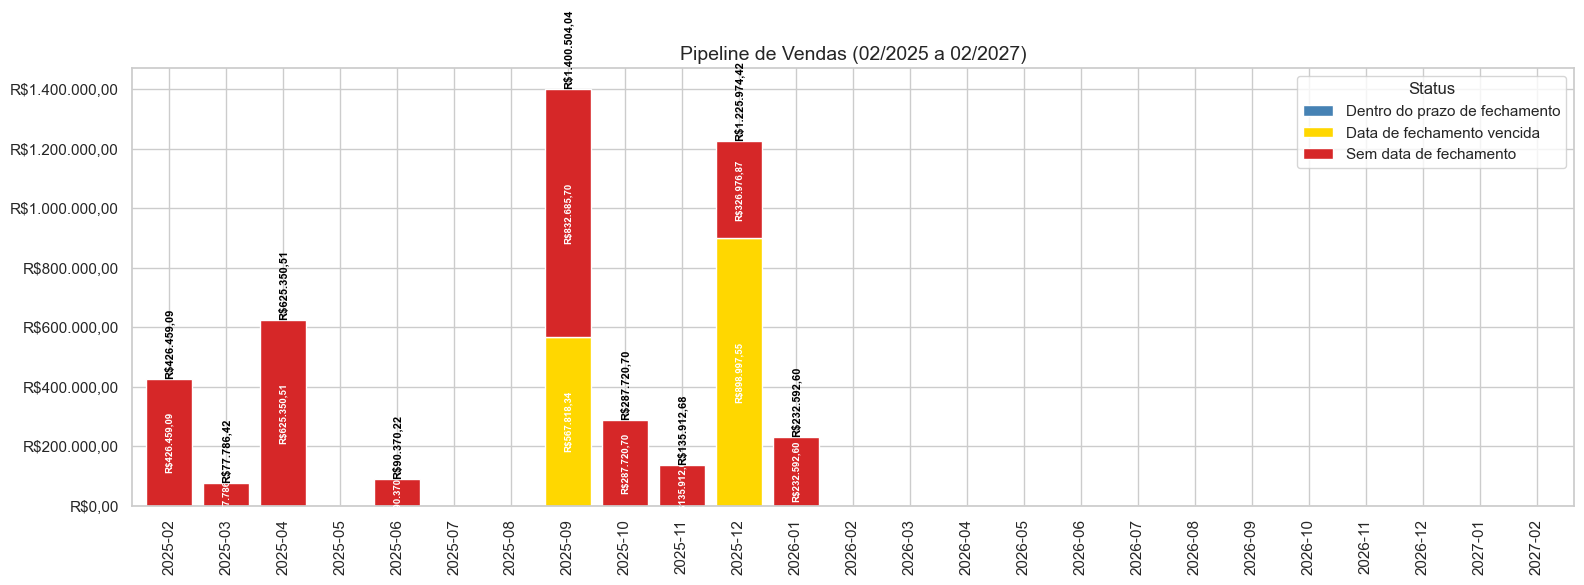

In [8]:
count = 0
reps_sem_cotacao = []
lista_reps = reps.df_reps['Código '].astype(str)

for i in lista_reps:
    #lista_representantes.loc[lista_representantes['Código ']==int(codigo_representante)]['Primeiro nome'].values[0]
    codigo_representante = i

    #Definição dos filtros
    #codigo_representante='12921'
    #112246a
    #codigo_representante=i

    representante_descricao = customers_info.df_customers_info.loc[customers_info.df_customers_info['Código representante']==codigo_representante]['Representante'].unique()

    clientes_contrato_estrategicos =['Cliente estratégico', 'Cliente com contrato']
    nome_representante = lista_representantes.loc[lista_representantes['Código ']==int(codigo_representante)]['Primeiro nome'].values[0]
    email_rep = lista_representantes.loc[lista_representantes['Código ']==int(codigo_representante)]['E-Mail'].values[0]
    razao_social_rep = lista_representantes.loc[lista_representantes['Código ']==int(codigo_representante)]['Razão Social'].values[0]
    atendimento_rep = lista_representantes.loc[lista_representantes['Código ']==int(codigo_representante)]['Atendimento'].values[0]

    quotes_concluded_rep = quotes_concluded.loc[
        quotes_concluded['Código representante']==codigo_representante
    ].reset_index(drop=True)

    quotes_criadas_rep = quotes_criadas.loc[
        quotes_criadas['Código representante']==codigo_representante
    ].reset_index(drop=True)


    n_cotacoes_fechadas = quotes_concluded_rep.loc[
        quotes_concluded_rep['Ano de fechamento'] == datetime.now().year, 
        'Cotação'
    ].nunique()
    
    n_cotacoes_criadas = quotes_criadas_rep.loc[
        quotes_criadas_rep['Ano de criação'] == datetime.now().year, 
        'Cotação'
    ].nunique()
    
    ind_fechamento = n_cotacoes_fechadas/n_cotacoes_criadas

    #Tabela de ultima revisão
    
    dfquotes_ult_rev_rep = quotes_ult_rev.loc[
        quotes_ult_rev['Código representante']==codigo_representante
    ].reset_index(drop=True)
    
    dfquotes_ult_rev_rep = pd.merge(dfquotes_ult_rev_rep,
             customers_info.df_customers_info,
             on=['Código cliente','Código organização de vendas'],
             how='left').rename(columns={'Cliente_x':'Cliente',
                                        'Cidade_x':'Cidade',
                                        'Estado_y':'Estado'})


    
    dfquotes_ult_rev_rep['Desconto cadastro'] = dfquotes_ult_rev_rep['Cat. de desconto cadastro'].apply(fc.desconto)

    dfquotes_ult_rev_rep['Desconto total'] = dfquotes_ult_rev_rep.apply(
        lambda row: fc.calcula_desconto_total(row['Desconto cotação'], row['Desconto cadastro']), axis=1
    )

    dfquotes_ult_rev_rep['Cat. desconto total'] = dfquotes_ult_rev_rep.apply(
                lambda row: fc.desconto_total_cotacao(row['Estado'], row['Desconto total']), axis=1)

    dfquotes_ult_rev_rep['Cat. desconto total'] = dfquotes_ult_rev_rep.apply(
                lambda row: fc.desconto_total_cotacao(row['Estado'], row['Desconto total']), axis=1)

    dfquotes_ult_rev_rep['Soma cotação'] = dfquotes_ult_rev_rep.groupby('Cotação')['Preço total'].transform('sum')
    
    dfquotes_ult_rev_rep = dfquotes_ult_rev_rep.loc[
                                                    (dfquotes_ult_rev_rep['Soma cotação']>50000)
                                                   ]

    #dfquotes_ult_rev_rep = dfquotes_ult_rev_rep.loc[(dfquotes_ult_rev_rep['Segmento'].isin(segmentos)) &
    #                                                (dfquotes_ult_rev_rep['Soma cotação']>50000)
    #                                               ]

    dfquotes_ult_rev_rep = dfquotes_ult_rev_rep.sort_values(
        by=['Segmento','Cliente', 'Cidade', 'Soma cotação'],
        ascending=[True,True, True, False]) # Soma cotação decrescente

    # 3. Ordenar pelo critério desejado
    colunas_exibir = ['Analista de vendas','Segmento','Cliente',
                                'Cidade',
                                'Cotação',
                                'Data de criação',
                                'Organização de vendas',
                                'Referência do cliente',
                                'Próximo followup',
                                'Data de fechamento esperada',
                                  'Descrição do produto',
                                'Quantidade',
                                'Cat. desconto total',
                                'Preço total'
                               ]


    #Tabela para colocar em anexo

    last_quotes_rep = last_quotes.loc[last_quotes['Código representante']==codigo_representante].reset_index(drop=True)

    last_quotes_rep = pd.merge(last_quotes_rep,
             customers_info.df_customers_info,
             on=['Código cliente','Código organização de vendas'],
             how='left').rename(columns={'Cliente_x':'Cliente',
                                        'Cidade_x':'Cidade',
                                        'Estado_y':'Estado'})
    last_quotes_rep['Desconto cadastro'] = last_quotes_rep['Cat. de desconto cadastro'].apply(fc.desconto)

    last_quotes_rep['Desconto total'] = last_quotes_rep.apply(
        lambda row: fc.calcula_desconto_total(row['Desconto cotação'], row['Desconto cadastro']), axis=1
    )

    last_quotes_rep['Cat. desconto total'] = last_quotes_rep.apply(
                lambda row: fc.desconto_total_cotacao(row['Estado'], row['Desconto total']), axis=1)

    last_quotes_rep['Soma cotação'] = last_quotes_rep.groupby('Cotação')['Preço total'].transform('sum')
    

    # 3. Ordenar pelo critério desejado
    colunas_exibir_last_quote = ['Cotação',
                                 'Revisão',
                                 'Status',
                                 'Data de criação',
                                 'Segmento',
                                 'Código cliente',
                                 'Cliente',
                                 'Cidade',
                                 'Organização de vendas',
                                 'Referência do cliente',
                                 'Próximo followup',
                                 'Data de fechamento esperada',
                                 'Produto',
                                 'Descrição do produto',
                                 'Quantidade',
                                 'Cat. desconto total',
                                 'Preço total'
                               ]

    last_quotes_rep = last_quotes_rep[colunas_exibir_last_quote]

    #Falta adicionar como anexo no e-mail e salvar.

    last_quotes_rep_excel_name = f'{razao_social_rep}/{datetime.now().strftime("%Y-%m-%d")}.xlsx'

    last_quotes_rep.to_excel(last_quotes_rep_excel_name, index=False)
    
    ###Emails de analistas e engenheiros de aplicação

    email_eng_aplicacao = pd.merge(dfquotes_ult_rev_rep[['Engenheiro de aplicação']].drop_duplicates(),
         contatos.df_contatos,
         how='left',
        left_on='Engenheiro de aplicação',
        right_on='Nome').dropna()['E-mail'].to_list()

    email_analistas = pd.merge(dfquotes_ult_rev_rep[['Analista de vendas']].drop_duplicates(),
         contatos.df_contatos,
         how='left',
        left_on='Analista de vendas',
        right_on='Nome').dropna()['E-mail'].to_list()
    
    email_copias = email_eng_aplicacao + email_analistas
    
    email_copias = "; ".join(email_copias)

    dfquotes_ult_rev_rep_email = dfquotes_ult_rev_rep[colunas_exibir]
    
    if dfquotes_ult_rev_rep_email.empty:
        print(f"Sem cotações para o representante: {razao_social_rep}")
        reps_sem_cotacao.append(razao_social_rep)  # Adiciona à lista
        continue  # Passa para o próximo loop

    # Função para formatar os valores no formato R$XX.XXX,XX
    def format_currency(val):
        if isinstance(val, (int, float)):
            return f"R${val:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
        return val


    # --- 1. Preparação dos Dados ---
    
    # Converter colunas de datas
    dfquotes_ult_rev_rep_email['Próximo followup'] = pd.to_datetime(
        dfquotes_ult_rev_rep_email['Próximo followup'], format='%d/%m/%y', dayfirst=True, errors='coerce'
    )
    dfquotes_ult_rev_rep_email['Data de fechamento esperada'] = pd.to_datetime(
        dfquotes_ult_rev_rep_email['Data de fechamento esperada'], format='%d/%m/%y', dayfirst=True, errors='coerce'
    )
    dfquotes_ult_rev_rep_email['Data de criação'] = pd.to_datetime(
        dfquotes_ult_rev_rep_email['Data de criação'], format='%d/%m/%y', dayfirst=True, errors='coerce'
    )
    
    # Definir data de referência (Hoje zerando horas)
    data_hoje = pd.Timestamp.now().normalize()
    
    # Lógica do Eixo X: Prioridade para Data Esperada, senão Data de Criação
    mask_sem_data = dfquotes_ult_rev_rep_email['Data de fechamento esperada'].isna()
    
    dfquotes_ult_rev_rep_email['Data_Eixo_X'] = dfquotes_ult_rev_rep_email['Data de fechamento esperada']
    dfquotes_ult_rev_rep_email.loc[mask_sem_data, 'Data_Eixo_X'] = dfquotes_ult_rev_rep_email.loc[mask_sem_data, 'Data de criação']
    
    # --- NOVA LÓGICA DE CATEGORIZAÇÃO ---
    # 1. Assume que está "No Prazo" (Azul)
    dfquotes_ult_rev_rep_email['Categoria'] = 'Dentro do prazo de fechamento'
    
    # 2. Se a data esperada existe e é menor que hoje -> "Vencido" (Amarelo)
    mask_vencido = (
        (~mask_sem_data) & 
        (dfquotes_ult_rev_rep_email['Data de fechamento esperada'] < data_hoje)
    )
    dfquotes_ult_rev_rep_email.loc[mask_vencido, 'Categoria'] = 'Data de fechamento vencida'
    
    # 3. Se não tem data esperada -> "Sem Previsão" (Vermelho)
    dfquotes_ult_rev_rep_email.loc[mask_sem_data, 'Categoria'] = 'Sem data de fechamento'
    # ------------------------------------
    
    # Criar coluna Mês/Ano para agrupamento
    dfquotes_ult_rev_rep_email['Mes_Ano'] = dfquotes_ult_rev_rep_email['Data_Eixo_X'].dt.to_period('M').astype(str)
    
    # Filtro de datas (Hoje +/- 12 meses)
    data_inicio = data_hoje - pd.DateOffset(months=12)
    data_fim = data_hoje + pd.DateOffset(months=12)
    
    df_filtrado = dfquotes_ult_rev_rep_email[
        (dfquotes_ult_rev_rep_email['Data_Eixo_X'] >= data_inicio) & 
        (dfquotes_ult_rev_rep_email['Data_Eixo_X'] <= data_fim)
    ].copy()
    
    # Cria o range completo de meses
    meses_ano_completo = pd.period_range(start=data_inicio, end=data_fim, freq='M').astype(str)
    
    # --- 2. Transformação para Tabela Dinâmica (Pivot) ---
    df_pivot = df_filtrado.pivot_table(
        index='Mes_Ano', 
        columns='Categoria', 
        values='Preço total', 
        aggfunc='sum',
        fill_value=0
    )
    
    # Reindexar linhas (meses)
    df_pivot = df_pivot.reindex(meses_ano_completo, fill_value=0)
    
    # Reindexar colunas para garantir Ordem e Cores corretas
    # Ordem desejada: Azul (Base), Amarelo (Meio), Vermelho (Topo) ou conforme preferir
    ordem_colunas = ['Dentro do prazo de fechamento', 'Data de fechamento vencida', 'Sem data de fechamento']
    for col in ordem_colunas:
        if col not in df_pivot.columns:
            df_pivot[col] = 0
    
    df_pivot = df_pivot[ordem_colunas]
    
    # --- 3. Gráfico ---
    sns.set(style='whitegrid')
    fig, ax = plt.subplots(figsize=(16, 6))
    
    # Definição das Cores correspondentes à ordem_colunas
    # No Prazo (Azul), Vencido (Amarelo Ouro), Sem Previsão (Vermelho)
    cores_mapa = ['steelblue', '#FFD700', '#d62728'] 
    
    df_pivot.plot(kind='bar', stacked=True, ax=ax, color=cores_mapa, width=0.8)
    
    # Formatar eixo Y
    def formatar_moeda(valor, _):
        return f'R${valor:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(formatar_moeda))
    
    # --- 4. Rótulos e Totais ---
    # Rótulos internos
    for c in ax.containers:
        labels = [formatar_moeda(v, None) if v > 0 else "" for v in c.datavalues]
        # Se a cor for Amarela (Vencido), usamos texto preto para contraste, senão branco
        cor_texto = 'black' if c.get_label() == 'Data de fechamento vencida' or c.get_label() == '_container1' else 'white'
        
        # Nota: O matplotlib as vezes nomeia containers genericamente, então forçamos a lógica visual:
        # O amarelo é o segundo item da lista de cores (índice 1). 
        # Mas para simplificar, vamos colocar sombra ou apenas cor fixa. 
        # Vou usar branco com negrito, costuma funcionar bem no Dourado escuro, senão troque para preto.
        
        ax.bar_label(c, labels=labels, label_type='center', fontsize=7, color='white', weight='bold', rotation=90)
    
    # Totais no topo
    totais_por_mes = df_pivot.sum(axis=1)
    for i, total in enumerate(totais_por_mes):
        if total > 0:
            ax.text(i, total, formatar_moeda(total, None), ha='center', va='bottom', fontsize=8, weight='bold', color='black', rotation=90)

    # Agrupa por categoria e soma o 'Preço total'
    totais_categoria = df_filtrado.groupby('Categoria')['Preço total'].sum()
    
    # Extrai os valores (usa 0.0 se a categoria não existir no filtro)
    val_azul = totais_categoria.get('Dentro do prazo de fechamento', 0.0)
    val_amarelo = totais_categoria.get('Data de fechamento vencida', 0.0)
    val_vermelho = totais_categoria.get('Sem data de fechamento', 0.0)
    
    # Função auxiliar de formatação (reutilizando a lógica)
    def fmt_moeda_html(valor):
        return f'R${valor:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')
    
    # Cria as strings formatadas
    txt_azul = fmt_moeda_html(val_azul)
    txt_amarelo = fmt_moeda_html(val_amarelo)
    txt_vermelho = fmt_moeda_html(val_vermelho)
    
    # Estilo
    plt.title(f'Pipeline de Vendas ({data_inicio.strftime("%m/%Y")} a {data_fim.strftime("%m/%Y")})', fontsize=14)
    plt.xlabel('')
    plt.ylabel('')
    plt.xticks(rotation=90)
    plt.legend(title='Status', loc='upper right')
    plt.tight_layout()
    
    plt.savefig(f'Follow-up - {razao_social_rep}.png', dpi=300)
    # plt.show()

    image_path = f'Follow-up - {razao_social_rep}.png'

    with open(image_path, "rb") as image_file:
        image_base64 = base64.b64encode(image_file.read()).decode("utf-8")

    # 9. Criar novo dataframe com followup até hoje + 7 dias ou NaN
    hoje = datetime.now()
    limite = hoje + timedelta(days=7)
    dfquotes_ult_rev_rep_email_fup = dfquotes_ult_rev_rep_email[
        (dfquotes_ult_rev_rep_email['Próximo followup'].isna()) |
        (dfquotes_ult_rev_rep_email['Próximo followup'] <= limite)
    ]
    
    # Exibir o dataframe filtrado
    dfquotes_ult_rev_rep_email = dfquotes_ult_rev_rep_email_fup

    dfquotes_ult_rev_rep_email['Próximo followup'] = dfquotes_ult_rev_rep_email['Próximo followup'].dt.strftime('%d/%m/%y')
    dfquotes_ult_rev_rep_email['Data de fechamento esperada'] = dfquotes_ult_rev_rep_email['Data de fechamento esperada'].dt.strftime('%d/%m/%y')
    
    dfquotes_ult_rev_rep_email['Preço total'] = dfquotes_ult_rev_rep_email['Preço total'].apply(format_currency)

    if 'Mes_Ano' in dfquotes_ult_rev_rep_email.columns:
        dfquotes_ult_rev_rep_email.drop(columns=['Mes_Ano'], inplace=True)

    #colunas_exibir.remove('Quantidade')
    nao_index = ['Descrição do produto',
                                'Quantidade',
                                'Cat. desconto total',
                                'Preço total']


    col_index = [coluna for coluna in colunas_exibir if coluna not in nao_index]

    table_to_html = dfquotes_ult_rev_rep_email.set_index(col_index,drop=True)
    table_to_html.drop(columns=["Data_Eixo_X", "Categoria"], inplace=True)

    assunto_email = fc.verificar_atendimento(atendimento_rep)

    tabelas_html = table_to_html.to_html(index=True)

    
    # HTML do gráfico para inserir no e-mail
    grafico_html = f'''
        <div class="section-content">
            <h2 class="section-title">Data de fechamento esperada conforme informações do EASY.</h2>
            <img src="data:image/png;base64,{image_base64}"
                         style="display: block; margin-left: auto; margin-right: auto; width: 50%;">
        </div>
    '''


    # Corpo do e-mail em HTML, incluindo gráficos e tabelas
    html_content = f'''
        <!DOCTYPE html>
        <html lang="pt-br">
        <head>
            <meta charset="UTF-8">
            <meta name="viewport" content="width=device-width, initial-scale=1.0">
            <title>Acompanhamento Vendas Técnicas</title>
            <link rel="stylesheet" href="https://fonts.googleapis.com/css2?family=Lato:wght@100;400;700&display=swap">
            <style>
                body {{
                    background-color: #F5F8FA;
                    font-family: 'Lato', sans-serif;
                    font-size: 14px;
                    color: #333;
                    margin: 0;
                    padding: 0;
                }}
                h1, h2, h3 {{
                    text-align: center; /* Centraliza os títulos */
                    color: #003366;
                    margin-bottom: 10px;
                }}
                h1 {{
                    font-size: 20px;
                }}
                h2 {{
                    font-size: 16px;
                    font-weight: bold;
                }}
                h3 {{
                    font-size: 16px;
                }}
                p {{
                    font-size: 13px;
                    line-height: 1.6;
                    margin: 0 0 10px 0;
                }}
                .content {{
                    width: fit-content; /* Ajusta à largura do conteúdo */
                    margin: 20px auto;
                    padding: 20px;
                    background-color: #fff;
                    border-radius: 8px;
                    box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);
                }}
                .section-title {{
                    font-weight: bold;
                    color: #005bbd;
                    margin-bottom: 10px;
                }}
                .section-content {{
                    margin-bottom: 20px;
                }}
                .table-wrapper {{
                    overflow-x: auto;
                    text-align: center; /* Centraliza as tabelas */
                }}
                table {{
                    width: auto; /* Remove largura fixa */
                    border-collapse: collapse;
                    table-layout: auto;
                    margin: 0 auto; /* Centraliza as tabelas */
                }}
                th, td {{
                    padding: 4px 8px;
                    font-size: 12px;
                    text-align: left;
                    border: 1px solid #ddd;
                    word-wrap: break-word;
                }}
                th {{
                    background-color: #f2f2f2;
                }}
                img {{
                    display: block; /* Garante que a imagem seja tratada como bloco */
                    margin: 0 auto; /* Centraliza as imagens */
                    width: auto; /* Ajusta ao tamanho original sem ultrapassar container */
                    height: auto;
                }}
            </style>
        </head>
        <body>
            <table width="100%" border="0" cellspacing="0" cellpadding="0">
                <tr>
                    <td align="center">
                        <div class="content">
                            <h1>{assunto_email}</h1>
                            <p>Prezado {nome_representante}, espero que este e-mail encontre você bem.</p>
                            <p>Hoje seu índice de fechamento de propostas está em {ind_fechamento:.2%} (com {n_cotacoes_fechadas} cotações fechadas e {n_cotacoes_criadas} cotações criadas). Nossa meta, em Vendas Técnicas, é de 30%.</p>
                            <p>Com base nos dados das cotações do EASY, você possui:</p>
                            <ul>
                                <li><b>{txt_azul}</b> previstas para fechamento nos próximos 12 meses;</li>
                                <li><b>{txt_amarelo}</b> com data prevista de fechamento vencida;</li>
                                <li><b>{txt_vermelho}</b> sem data de fechamento esperada.</li>
                            </ul>
                            <p>Deixamos, também, em anexo todas as cotações geradas pelo escritório dos últimos 3 anos, para facilitar seu gerenciamento da região.</p>
                            <p>Peço realizar o follow-up das cotações ou enviar para seu escritório realizar.</p>
                            {grafico_html}
                            <div class="section-content">
                                <h2 class="section-title">Tabela de propostas acima de R$50.000,00 que precisam de follow-up</h2>
                                {tabelas_html}
                            </div>

                            <div class="section-content">
                                <h2 class="section-title">Observações</h2>
                                <p>Por favor, entre em contato com seu analista caso haja qualquer dúvida ou necessidade de mais informações.</p>
                                <p>Atenciosamente, <br>Equipe de Vendas Técnicas</p>
                            </div>
                        </div>
                    </td>
                </tr>
            </table>
        </body>
        </html>
    '''
    
    # Pode vir de outra variável no seu código
    to_addr = 'mateuslm@weg.net'  # ou email_rep
    #to_addr = f'{email_rep}'  # ou email_rep

    #email_copias = email_copias
    email_copias = 'mateuslm@weg.net'

    text = html_content
    
    from_addr = fc.verificar_atendimento_from(atendimento_rep)

    # 4) Monta a mensagem
    msg = EmailMessage()
    msg['Subject'] = assunto_email + ' - ' + razao_social_rep
    msg['From'] = from_addr
    msg['To'] = to_addr
    msg['Cc'] = email_copias
    msg['Bcc'] = "wmo-vendastecnicas@weg.net"
    msg.add_alternative(html_content, subtype="html", charset="utf-8")
    
    def split_addr_list(s):
        if not s:
            return []
        # divide por vírgula e remove espaços
        return [a.strip() for a in s.split(';') if a.strip()]

    to_list = split_addr_list(to_addr)
    cc_list = split_addr_list(email_copias)
    bcc_list = ["wmo-vendastecnicas@weg.net"] # Bcc apenas no envelope

    all_recipients = to_list + cc_list + bcc_list
    
    # 6. Anexar o arquivo Excel
    from email.mime.base import MIMEBase
    from email import encoders
    
    # --- 3. Anexar o arquivo Excel (Corrigido) ---
    try:
        with open(last_quotes_rep_excel_name, 'rb') as f:
            file_data = f.read()
            file_name = f'{datetime.now().strftime("%Y-%m-%d")}-{razao_social_rep}.xlsx'
            
            # O EmailMessage lida automaticamente com a codificação Base64
            msg.add_attachment(
                file_data,
                maintype='application',
                subtype='vnd.openxmlformats-officedocument.spreadsheetml.sheet', # Tipo MIME explícito para .xlsx
                filename=file_name
            )
        print("Arquivo anexado com sucesso.")
    
    except Exception as e:
        print(f"Erro ao anexar o arquivo: {e}")

    smtp_server = smtplib.SMTP('mail.weg.net')
    smtp_server.send_message(msg, from_addr=from_addr, to_addrs=all_recipients)

    print(f'E-mail enviado com sucesso via SMTP para {to_addr}')    
    count +=1
    
    if count == 1:
        continuar = input('Deseja continuar? (Sim/Não): ').strip().lower()
        if continuar == 'sim':
            count = 0  # Reinicia o contador para continuar por mais 20 iterações
        elif continuar =='enviar todos':
            count = 2
        else:
            print("Encerrando o loop.")
            break

In [ ]:
last_quotes_rep.columns